<a href="https://colab.research.google.com/github/harishraghavhr7/Mock_interviewer/blob/main/Confident__classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data from Google Drive

First, we need to mount Google Drive to access the dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

After mounting Google Drive, please update the `TRAIN_DIR` and `VAL_DIR` variables below to reflect the correct paths to your dataset within Google Drive. Make sure your dataset structure (e.g., `dataset/train`, `dataset/val` with class subdirectories) is maintained under the specified paths.

In [ ]:
import os
import cv2
import torch
import timm
import numpy as np

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from albumentations.pytorch import ToTensorV2
import albumentations as A

# =========================
# CONFIG
# =========================

TRAIN_DIR = "/content/drive/MyDrive/faces/train"
VAL_DIR = "/content/drive/MyDrive/faces/val"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# AUGMENTATIONS
# =========================

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.HorizontalFlip(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    A.Rotate(limit=10, p=0.5),

    A.GaussianBlur(p=0.2),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

# =========================
# CUSTOM DATASET
# =========================

class AlbumentationsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.dataset = ImageFolder(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image_path, label = self.dataset.samples[idx]

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label

# =========================
# LOAD DATA
# =========================

train_dataset = AlbumentationsDataset(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = AlbumentationsDataset(
    VAL_DIR,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =========================
# MODEL
# =========================

model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=2
)

model = model.to(DEVICE)

# =========================
# LOSS + OPTIMIZER
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

# =========================
# TRAIN LOOP
# =========================

best_val_acc = 0

for epoch in range(EPOCHS):

    # ---------------------
    # TRAIN
    # ---------------------

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()

        train_total += labels.size(0)

    train_acc = train_correct / train_total

    # ---------------------
    # VALIDATION
    # ---------------------

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

    # ---------------------
    # SAVE BEST MODEL
    # ---------------------

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_confidence_model.pth"
        )

        print("Best model saved!")

print("Training Complete")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1/15
Train Accuracy: 0.7394
Validation Accuracy: 0.4889
Best model saved!
Epoch 2/15
Train Accuracy: 0.9507
Validation Accuracy: 0.5111
Best model saved!
Epoch 3/15
Train Accuracy: 0.9789
Validation Accuracy: 0.4889
Epoch 4/15
Train Accuracy: 0.9930
Validation Accuracy: 0.6000
Best model saved!
Epoch 5/15
Train Accuracy: 0.9930
Validation Accuracy: 0.6889
Best model saved!
Epoch 6/15
Train Accuracy: 1.0000
Validation Accuracy: 0.9333
Best model saved!
Epoch 7/15
Train Accuracy: 1.0000
Validation Accuracy: 0.9333
Epoch 8/15
Train Accuracy: 1.0000
Validation Accuracy: 0.9778
Best model saved!
Epoch 9/15
Train Accuracy: 1.0000
Validation Accuracy: 0.9333
Epoch 10/15
Train Accuracy: 1.0000
Validation Accuracy: 0.8889
Epoch 11/15
Train Accuracy: 1.0000
Validation Accuracy: 0.8889
Epoch 12/15
Train Accuracy: 1.0000
Validation Accuracy: 0.9333
Epoch 13/15
Train Accuracy: 1.0000
Validation Accuracy: 0.9333
Epoch 14/15
Train Accuracy: 0.9930
Validation Accuracy: 0.9556
Epoch 15/15
Train A

Model Loaded Successfully

Prediction Result
------------------------------
Predicted Class : confident
Confidence Score: 1.0000


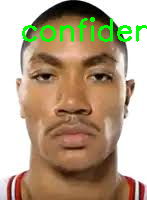

In [ ]:
import torch
import timm
import cv2
import numpy as np
import albumentations as A

from albumentations.pytorch import ToTensorV2
from google.colab.patches import cv2_imshow # Import cv2_imshow

# =====================================
# CONFIG
# =====================================

MODEL_PATH = "best_confidence_model.pth"

IMAGE_PATH = "/content/download.jpg"

IMG_SIZE = 224

CLASSES = [
    "confident",
    "non_confident"
]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =====================================
# LOAD MODEL
# =====================================

model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE)
)

model = model.to(DEVICE)

model.eval()

print("Model Loaded Successfully")

# =====================================
# IMAGE TRANSFORM
# =====================================

transform = A.Compose([

    A.Resize(IMG_SIZE, IMG_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()

])

# =====================================
# LOAD IMAGE
# =====================================

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise ValueError(f"Could not read image: {IMAGE_PATH}")

original_image = image.copy()

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# =====================================
# PREPROCESS
# =====================================

augmented = transform(image=image)

image_tensor = augmented["image"]

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(DEVICE)

# =====================================
# INFERENCE
# =====================================

with torch.no_grad():

    outputs = model(image_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    confidence_score, prediction = torch.max(
        probabilities,
        dim=1
    )

predicted_class = CLASSES[prediction.item()]

score = confidence_score.item()

# =====================================
# RESULTS
# =====================================

print("\nPrediction Result")
print("-" * 30)

print(f"Predicted Class : {predicted_class}")

print(f"Confidence Score: {score:.4f}")

# =====================================
# OPTIONAL DISPLAY
# =====================================

text = f"{predicted_class} ({score:.2f})"

cv2.putText(
    original_image,
    text,
    (20, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    2
)

cv2_imshow(original_image) # Removed the window name argument

# cv2.waitKey(0) # Removed

# cv2.destroyAllWindows() # Removed

In [ ]:
# Example: If your dataset is in 'My Drive/my_image_dataset/dataset'
# TRAIN_DIR = "/content/drive/MyDrive/my_image_dataset/dataset/train"
# VAL_DIR = "/content/drive/MyDrive/my_image_dataset/dataset/val"